# [DRIVE] UNet -- AGG FOLD LOOPS -- seed 1337

In [1]:
import sys, os
sys.path.append(os.path.abspath('../../'))

print( os.getcwd())
sys.path


c:\Users\s1005\OneDrive\文件\PLM_DOCS\code\githubs\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\notebooks\train_all


['C:\\Users\\s1005\\AppData\\Local\\Programs\\Python\\Python310\\python310.zip',
 'C:\\Users\\s1005\\AppData\\Local\\Programs\\Python\\Python310\\DLLs',
 'C:\\Users\\s1005\\AppData\\Local\\Programs\\Python\\Python310\\lib',
 'C:\\Users\\s1005\\AppData\\Local\\Programs\\Python\\Python310',
 'c:\\Users\\s1005\\OneDrive\\文件\\PLM_DOCS\\code\\githubs\\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\\venv_310_1',
 '',
 'c:\\Users\\s1005\\OneDrive\\文件\\PLM_DOCS\\code\\githubs\\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\\venv_310_1\\lib\\site-packages',
 'c:\\Users\\s1005\\OneDrive\\文件\\PLM_DOCS\\code\\githubs\\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation']

In [2]:
from src.models.unet import UNet
print(UNet)

<class 'src.models.unet.UNet'>


In [3]:
from pathlib import Path
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# CHANGE THESE

In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED   = 1337
DATASET = "DRIVE" # "DRIVE" | "STARE" | "CHASEDB1"

PATCH_SIZE = 128
VAL_WINDOW  = PATCH_SIZE
VAL_OVERLAP = 0.25

VESSEL_BIAS=0.7
MIN_PERCENT_VESSEL=0.008
V_MULT=30
DENSE_BIAS=None
BATCH_SIZE=2

IMG_SIZE=512

EPOCHS = 50
warmup_epochs = 5

FOLDS = 10
FOLD_ID = 8

THRESHOLD_EVAL = 0.5


MODEL_NAME = "LadderNet"
TITLE     = f"[{DATASET}] {MODEL_NAME} NEW SPLIT ({FOLDS} folds) epochs={EPOCHS}"
SAVE_ROOT = Path(f"../../../../pth/{MODEL_NAME}_{DATASET}_NEWSPLIT")     # a clean experiment folder
SAVE_CKPT = SAVE_ROOT / "checkpoints"
SAVE_PRED = SAVE_ROOT / "predictions"   # per-image logits/prob/masks
SAVE_VIZ  = SAVE_ROOT / "visuals"       # PNG overlays per test image
SAVE_LOGS = SAVE_ROOT / "logs"
for d in [SAVE_ROOT, SAVE_CKPT, SAVE_PRED, SAVE_VIZ, SAVE_LOGS]: d.mkdir(parents=True, exist_ok=True)

DATASET_ROOT        = f"../../../../Retinal_Vessel_Segmentation_Datasets/{DATASET}/"
DATASET_LABELFOLDER = "1st_manual"




# IMPORTS

In [5]:
import os, json, math, time, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import LambdaLR
import matplotlib.pyplot as plt

# --- data utils ---
from src.data.splits import (
    split_drive_20_20,
    split_chase_subjectwise_20_8,
    split_stare_leave_one_out,
    stare_loo_fold,
    chase_mc_balanced_splits,
    drive_mc_balanced_splits,

    chase_random_subject_split,

)

from src.data.dataloader import make_loaders
from src.data.augmentations import get_train_augs, get_val_augs

# use YOUR metrics utilities
from src.training.metrics import (
    confusion_counts,
    dice as dice_metric,
    iou as iou_metric,
    roc_auc as roc_auc_metric,
    pr_auc as pr_auc_metric,
    acc_from_counts,
    recall_from_counts,          # sensitivity
    specificity_from_counts,     # specificity
    cldice
)


from src.training.train_cv import (
    sliding_window_forward_logits,
    update_dataset,
    #train_one_epoch,
    #validate_loss_only,
    #atomic_torch_save,
    saveTrainVal
)


# --- evaluation & visualization ---
from src.evaluation.evaluate import evaluate_and_print
from src.evaluation.visualization import visualize_samples

c:\Users\s1005\OneDrive\文件\PLM_DOCS\code\githubs\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\venv_310_1\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# helpers and config

In [6]:
splits, counts = drive_mc_balanced_splits(
    DATASET_ROOT, label_folder=DATASET_LABELFOLDER, n_runs=FOLDS
)

[DRIVE] Run 00 TEST images: ['31_training.png', '27_training.png', '33_training.png', '40_training.png', '35_training.png', '04_test.png', '30_training.png', '20_test.png', '11_test.png', '24_training.png', '38_training.png', '08_test.png', '25_training.png', '19_test.png', '01_test.png', '13_test.png', '14_test.png', '36_training.png', '39_training.png', '06_test.png']
[DRIVE] Run 01 TEST images: ['11_test.png', '28_training.png', '32_training.png', '08_test.png', '02_test.png', '26_training.png', '38_training.png', '29_training.png', '05_test.png', '16_test.png', '25_training.png', '19_test.png', '39_training.png', '03_test.png', '04_test.png', '21_training.png', '12_test.png', '20_test.png', '27_training.png', '23_training.png']
[DRIVE] Run 02 TEST images: ['36_training.png', '10_test.png', '21_training.png', '37_training.png', '23_training.png', '15_test.png', '34_training.png', '09_test.png', '02_test.png', '19_test.png', '16_test.png', '06_test.png', '03_test.png', '20_test.png',

In [7]:
# --- model factory (fresh per fold) ---


def make_model(MODEL_NAME, train_loader = None) -> nn.Module:
    if MODEL_NAME == "MATHFI":
        # --- loss ---
        from src.models.wrappers.dpcn_concat_unet import DPCNConcatUNet
        BASE_KW = {"cbam_reduction": 16}

        if train_loader is not None:
            from src.training.loss_functions import DiceBCEComplementLoss

            def estimate_class_weights(loader, max_batches=20):
                with torch.no_grad():
                    s = 0.0; n = 0
                    for i, b in enumerate(loader):
                        s += b["mask"].float().mean().item(); n += 1
                        if i+1 >= max_batches: break
                p = max(1e-6, min(1-1e-6, s / max(1, n)))
                w1 = 1.0 / p; w0 = 1.0 / (1.0 - p)
                s2 = w0 + w1; w0 = 2.0 * w0 / s2; w1 = 2.0 * w1 / s2
                return w0, w1

            w0, w1 = estimate_class_weights(train_loader, max_batches=20)
            loss_fn = DiceBCEComplementLoss(w0=w0, w1=w1, dice_weight=0.5, bce_weight=0.5,
                                        exact_equation=False, reduction="mean")

        else: loss_fn = None
        # --- model ---
        return DPCNConcatUNet(
            in_ch=1, enh_channels=64, iters=6,
            threshold_mode="scaled_vat", half_life=2.0,
            reduce_to=64, base_kwargs=BASE_KW
        ).to(DEVICE), loss_fn

    elif MODEL_NAME == "FR-UNet":
        sys.path.append(os.path.abspath('../../../FR-UNet/'))
        loss_fn = nn.BCEWithLogitsLoss()
        from models.fr_unet import FR_UNet
        return FR_UNet().to(DEVICE), loss_fn

    elif MODEL_NAME == "UNet":
      from src.models.orig_unet import UNet
      model = UNet(in_channels=1, out_channels=2).to(DEVICE)
      class_weights = torch.tensor([1.30, 1.70], device=DEVICE)  # was ~[1.55,1.65] → ease BG tilt
      loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)  # no label_smoothing
      return model, loss_fn
    
    elif MODEL_NAME == "LadderNet":
        from LadderNet import LadderNetv6
        layers = 4
        filters = 10
        model = LadderNetv6(
            num_classes=2,layers=layers,filters=filters,inplanes=1).to(DEVICE)
        return  model, torch.nn.CrossEntropyLoss()
                
    elif MODEL_NAME == "LWNet":
        from LWNet import WNet
        model_core = WNet(in_c=1,
                  n_classes=2,
                  layers=(8,16,32),
                  k_sz=3,
                  up_mode='transp_conv',
                  conv_bridge=True,
                  shortcut=True).to(DEVICE)
        
        return model_core, torch.nn.CrossEntropyLoss()

def add_metrics(model_name, root, label_folder, img_size, ckpt_path, threshold_eval, all_metrics):


        stem = Path(ckpt_path).stem  # "STARE_fold00"
        fold_id = int(stem.split("fold")[-1])  # 0
        #print(f"checkpoint_path: {ckpt_path}\nfold_id:{fold_id}")

        _, te_pairs, _ = splits[fold_id]

        _, test_loader = make_loaders(
            train_pairs=te_pairs, val_pairs=te_pairs,
            image_size=img_size, batch_size=BATCH_SIZE, num_workers=1,
            seed=SEED, strict_fov=True,
            augs_train=None, augs_val=get_val_augs(img_size),
        )

        model, _ = make_model(model_name)
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        model.eval()

        img_stem = f"fold{fold_id:02d}_testset"

        print(
            f"\n== [F{fold_id:02d}] {img_stem} == \n")


        # 6a) metrics
        # 6a) metrics — use YOUR metrics module via our wrapper
        m = evaluate_and_print(model, test_loader, device = DEVICE, threshold=threshold_eval, compute_auc=True)
        m["fold_id"]  = fold_id
        m["image_id"] = img_stem
        all_metrics.append(m)



In [8]:
def atomic_torch_save(state, path: Path):
    """
    Write to a temp file then atomically replace the target.
    Prevents duplicate files and avoids partial checkpoints on crashes.
    """
    path = Path(path)
    tmp  = path.with_suffix(path.suffix + ".partial")

    # clean any stale tmp
    try:
        tmp.unlink()
    except FileNotFoundError:
        pass

    # write tmp, flush to disk, then atomic replace
    with open(tmp, "wb") as f:
        torch.save(state, f)
        f.flush()
        os.fsync(f.fileno())
    os.replace(tmp, path)  # atomic on POSIX & works fine in Colab/Drive

def center_crop_like(y: torch.Tensor, H: int, W: int) -> torch.Tensor:
    # Works for (N,H,W) tensors
    _, h, w = y.shape
    dh = max(0, (h - H) // 2)
    dw = max(0, (w - W) // 2)
    return y[:, dh:dh+H, dw:dw+W]

def prepare_target_for_ce(y: torch.Tensor, logits: torch.Tensor) -> torch.Tensor:
    """
    Convert y to class-index map of shape (N,H,W) for CrossEntropyLoss.
    Handles:
      - (N,1,H,W) masks with 0/1 or 0/255
      - (N,C,H,W) one-hot masks
      - (N,H,W) already-correct masks
    Also crops y to match logits spatial size if needed.
    """
    # If float masks, binarize/clean them (0/1)
    if y.dtype.is_floating_point:
        # If labels are 0..255, normalize; otherwise just round 0/1 floats
        if y.max() > 1.0:
            y = (y / 255.0).round()
        else:
            y = y.round()

    # Shape handling
    if y.ndim == 4:
        # (N,1,H,W) or (N,C,H,W)
        if y.size(1) == 1:
            y = y[:, 0]                 # -> (N,H,W)
        else:
            y = y.argmax(dim=1)         # -> (N,H,W) from one-hot
    elif y.ndim == 3:
        pass                            # already (N,H,W)
    else:
        raise ValueError(f"Unexpected target shape {y.shape}; expected (N,H,W) or (N,C,H,W)")

    # Ensure int64 class indices
    y = y.long()

    # Spatial align (e.g., if model uses valid 3x3 and shrinks)
    H, W = logits.shape[-2:]
    if (y.shape[-2] != H) or (y.shape[-1] != W):
        y = center_crop_like(y, H, W)

    # Sanity: class ids must be in [0, C-1]
    C = logits.shape[1]
    if y.min() < 0 or y.max() >= C:
        raise ValueError(f"Target has labels outside [0,{C-1}]: min={int(y.min())} max={int(y.max())}")

    return y

def train_one_epoch(model, loader, optimizer, scaler, loss_fn):
    model.train()
    total, n = 0.0, 0
    for batch in loader:
        x = batch["image"].to(DEVICE, non_blocking=True)  # [B,1,H,W]
        y = batch["mask"].to(DEVICE,  non_blocking=True)  # [B,1,H,W]

        # Optional: mask labels outside FOV if present (keeps loss fair)
        if "fov" in batch:
            fov = batch["fov"].to(DEVICE, non_blocking=True)
            y = y * (fov > 0.5).float()

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type="cuda", enabled=(DEVICE=="cuda")):
            logits = model(x)          # ← PURE UNET: no fov passed
            y_idx  = prepare_target_for_ce(y, logits)     # (N,H,W) int64
            loss   = loss_fn(logits, y_idx)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.5)
        scaler.step(optimizer)
        scaler.update()
        #scheduler.step()

        total += loss.item() * x.size(0)
        n     += x.size(0)
    return total / max(1, n)

@torch.no_grad()
def validate_loss_only(model, loader, loss_fn):
    model.eval()
    total, n = 0.0, 0
    for batch in loader:
        x = batch["image"].to(DEVICE, non_blocking=True)
        y = batch["mask"].to(DEVICE,  non_blocking=True)

        if "fov" in batch:
            fov = batch["fov"].to(DEVICE, non_blocking=True)
            y = y * (fov > 0.5).float()

        with torch.amp.autocast(device_type="cuda", enabled=(DEVICE=="cuda")):
            logits = model(x)          # ← PURE UNETclass_weights
            y_idx  = prepare_target_for_ce(y, logits)     # (N,H,W) int64
            loss   = loss_fn(logits, y_idx)

        total += loss.item() * x.size(0)
        n     += x.size(0)
    return total / max(1, n)

# MAIN RUN

In [9]:
# --- main LOO run ---
def run_drive_experiment(
    model_name,
    root,
    label_folder,
    dataset,
    epochs,
    warmup,
    V_MULT,
    batch_size,
    img_size,
    patch_train,
    patch_size,
    vessel_bias_p,
    threshold_eval,
    folds,
    fold_id,
    save_ckpt,
    save_viz,
    title,
    save_logs,
    chckpnt_paths=None,
    SEED=1337,
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu",
    splits = None
):
    rng = np.random.RandomState(SEED)
    all_metrics = []
    per_image_preds = {}   # img_stem -> dict(prob_path, bin_path, fold_id)

    while fold_id < folds:

        # add checkpoint paths to metric list
        if chckpnt_paths:
            for ckpt in chckpnt_paths:
                add_metrics(model_name,
                            root,
                            label_folder,
                            img_size, ckpt,
                            threshold_eval, all_metrics)
            chckpnt_paths.clear()

        if splits is None:
            splits, counts = drive_mc_balanced_splits(
                root, label_folder=label_folder, n_runs=folds
            )

        print(f"\n========== {model_name} {dataset} NEW SPLIT, Fold {fold_id+1}/{folds} ==========")
        print(f"\n\t Chosen test subjects: {splits[fold_id][2]}\n")



        ##########################
        # 2) split dataset
        tr_pairs, te_pairs, _ = splits[fold_id]

        # 2a) carve val deterministically from train
        val_pairs = tr_pairs[-4:]
        tr_pairs_ = tr_pairs[:-4]

        # 3) loaders
        train_loader, val_loader = make_loaders(
            train_pairs=tr_pairs_, val_pairs=val_pairs,
            image_size=img_size, batch_size=batch_size, num_workers=2,
            seed=SEED + fold_id, strict_fov=True,
            augs_train=get_train_augs(img_size),
            augs_val=get_val_augs(img_size),
            patch_train=patch_train, patch_size=patch_size,
            vessel_bias_p=vessel_bias_p, virtual_mult=V_MULT,
        )

        _, test_loader = make_loaders(
            train_pairs=te_pairs, val_pairs=te_pairs,
            image_size=img_size, batch_size=batch_size, num_workers=2,
            seed=SEED, strict_fov=True,
            augs_train=None, augs_val=get_val_augs(img_size),
            patch_train=False
        )

        # 4) model & optimizer
        model, loss_fn = make_model(model_name, test_loader)

        optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
        scaler    = torch.amp.GradScaler("cuda", enabled=(DEVICE=="cuda"))
        def lr_lambda(e):
            if e < warmup: return (e+1)/max(1, warmup)
            progress = (e - warmup) / max(1, epochs - warmup)
            return 0.5 * (1 + math.cos(math.pi * progress))
        scheduler = LambdaLR(optimizer, lr_lambda)

        # 5) train with best-val checkpointing
        best_val = float("inf")
        ckpt_path = save_ckpt / f"{dataset}_fold{fold_id:02d}.pth"

        train_losses, val_losses = [], []

        for ep in range(1, epochs+1):
            update_dataset(train_loader.dataset, ep)
            t0=time.time()
            tr_loss  = train_one_epoch(model, train_loader, optimizer, scaler, loss_fn)
            val_loss = validate_loss_only(model, val_loader, loss_fn)
            scheduler.step()
            print(f"[F{fold_id:02d} E{ep:03d}] train={tr_loss:.4f} val={val_loss:.4f} "
                  f"lr={optimizer.param_groups[0]['lr']:.2e} time={(time.time()-t0):.1f}s")


            train_losses.append(float(tr_loss))
            val_losses.append(float(val_loss))

            if val_loss < best_val:
                best_val = val_loss
                atomic_torch_save(model.state_dict(), ckpt_path)
                print(f"\tCHECKPOINT SAVED: {ckpt_path}")

        save_path = save_viz / f"TrainVsVal__fold{fold_id:02d}.png"
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        epochs_val = np.arange(1, len(train_losses) + 1)
        saveTrainVal(epochs_val, fold_id, train_losses, val_losses, save_path, title)


        ####################
        #  6) eval on left-out image using best checkpoint
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        model.eval()


        ####################
        #  6a) metrics + print
        m = evaluate_and_print(model, test_loader, device = DEVICE, threshold=threshold_eval, compute_auc=True)
        m["fold_id"]  = fold_id
        batch = next(iter(test_loader))
        img_path = batch["image_path"][0]
        img_stem = Path(img_path).stem
        m["image_id"] = img_stem
        all_metrics.append(m)

        ###################
        # 6b) visualization
        save_viz_dir = save_viz / f"testSet__fold{fold_id:02d}.png"
        visualize_samples(
            model=model,
            dataloader=test_loader,
            n_rows=20,
            device=DEVICE,
            threshold=0.5,
            clamp_pred_with_fov=True,
            figsize_per_row=(12, 3),
            is_save = True,
            save_dir = save_viz_dir
        )
        print(f"\t== Visualization SAVED TO FILE: {save_viz_dir} ==")



        fold_id = fold_id + 1

        # END OF FOLD LOOP



    # 7) aggregate & save CSV
    import csv
    keys = ["fold_id","image_id","SEN","SPE", "CLDICE", "ACC","Dice","IoU","AUC","AP"]
    csv_path = save_logs / f"{dataset}_newSplit_perfold.csv"
    with open(csv_path, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=keys); w.writeheader()
        for row in all_metrics: w.writerow({k: row.get(k, "") for k in keys})

    # mean±std
    def _ms(name):
        arr = np.array([r[name] for r in all_metrics if not np.isnan(r[name])], dtype=float)
        return float(arr.mean()), float(arr.std(ddof=1)) if arr.size > 1 else 0.0
    summary = {k: _ms(k) for k in ["SEN","SPE","CLDICE","ACC","Dice","IoU","AUC","AP"]}
    print(f"\n=== {model_name} {dataset} NEW SPLITS ({folds} folds) — mean ± std ===")
    for k,(mu,sig) in summary.items():
        print(f"{k}: {mu:.4f} ± {sig:.4f}")

    with open(save_logs / f"{dataset}_newSplit_summary.json","w") as f:
        json.dump({k: {"mean": mu, "std": sig} for k,(mu,sig) in summary.items()}, f, indent=2)

    # 8) (optional) gallery index of unbiased predictions
    with open(save_logs / f"{dataset}_newSplit_per_image_preds.json","w") as f:
        json.dump(per_image_preds, f, indent=2)

    return all_metrics, summary



== [F00] fold00_testset == 



C:\Users\s1005\AppData\Local\Temp\ipykernel_14808\1055681227.py:86: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=DE

=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.7607
Specificity    : 0.9868
clDice         : 0.7893
Accuracy       : 0.9673
Dice           : 0.7959
IoU            : 0.6618
Precision      : 0.8427
FPR            : 0.0132
FDR            : 0.1573
Dice_thin      : 0.4967
Dice_thick     : 0.6679
ROC_AUC        : 0.9822
PR_AUC         : 0.8902
-- Micro (pooled over all pixels) --
Sensitivity    : 0.7568
Specificity    : 0.9868
F1/Dice        : 0.7970
Accuracy       : 0.9673
IoU            : 0.6625
Precision      : 0.8417
FPR            : 0.0132
FDR            : 0.1583
ROC_AUC        : 0.9814
PR_AUC         : 0.8857

== [F01] fold01_testset == 



C:\Users\s1005\AppData\Local\Temp\ipykernel_14808\1055681227.py:86: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=DE

=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.7337
Specificity    : 0.9887
clDice         : 0.7795
Accuracy       : 0.9670
Dice           : 0.7874
IoU            : 0.6509
Precision      : 0.8579
FPR            : 0.0113
FDR            : 0.1421
Dice_thin      : 0.4901
Dice_thick     : 0.6595
ROC_AUC        : 0.9823
PR_AUC         : 0.8883
-- Micro (pooled over all pixels) --
Sensitivity    : 0.7313
Specificity    : 0.9887
F1/Dice        : 0.7889
Accuracy       : 0.9670
IoU            : 0.6514
Precision      : 0.8564
FPR            : 0.0113
FDR            : 0.1436
ROC_AUC        : 0.9816
PR_AUC         : 0.8846

== [F02] fold02_testset == 



...

=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.7644
Specificity    : 0.9845
clDice         : 0.7848
Accuracy       : 0.9656
Dice           : 0.7886
IoU            : 0.6525
Precision      : 0.8202
FPR            : 0.0155
FDR            : 0.1798
Dice_thin      : 0.4866
Dice_thick     : 0.6594
ROC_AUC        : 0.9809
PR_AUC         : 0.8794
-- Micro (pooled over all pixels) --
Sensitivity    : 0.7613
Specificity    : 0.9845
F1/Dice        : 0.7892
Accuracy       : 0.9656
IoU            : 0.6518
Precision      : 0.8191
FPR            : 0.0155
FDR            : 0.1809
ROC_AUC        : 0.9805
PR_AUC         : 0.8771

== [F06] fold06_testset == 



C:\Users\s1005\AppData\Local\Temp\ipykernel_14808\1055681227.py:86: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=DE

=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.7567
Specificity    : 0.9863
clDice         : 0.7807
Accuracy       : 0.9667
Dice           : 0.7908
IoU            : 0.6550
Precision      : 0.8364
FPR            : 0.0137
FDR            : 0.1636
Dice_thin      : 0.4886
Dice_thick     : 0.6633
ROC_AUC        : 0.9818
PR_AUC         : 0.8868
-- Micro (pooled over all pixels) --
Sensitivity    : 0.7542
Specificity    : 0.9863
F1/Dice        : 0.7925
Accuracy       : 0.9667
IoU            : 0.6563
Precision      : 0.8349
FPR            : 0.0137
FDR            : 0.1651
ROC_AUC        : 0.9810
PR_AUC         : 0.8828

== [F07] fold07_testset == 



C:\Users\s1005\AppData\Local\Temp\ipykernel_14808\1055681227.py:86: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=DE

=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.7826
Specificity    : 0.9804
clDice         : 0.7861
Accuracy       : 0.9635
Dice           : 0.7813
IoU            : 0.6425
Precision      : 0.7852
FPR            : 0.0196
FDR            : 0.2148
Dice_thin      : 0.4767
Dice_thick     : 0.6500
ROC_AUC        : 0.9774
PR_AUC         : 0.8676
-- Micro (pooled over all pixels) --
Sensitivity    : 0.7788
Specificity    : 0.9804
F1/Dice        : 0.7815
Accuracy       : 0.9635
IoU            : 0.6414
Precision      : 0.7843
FPR            : 0.0196
FDR            : 0.2157
ROC_AUC        : 0.9769
PR_AUC         : 0.8647
[DRIVE] Run 00 TEST images: ['31_training.png', '27_training.png', '33_training.png', '40_training.png', '35_training.png', '04_test.png', '30_training.png', '20_test.png', '11_test.png', '24_training.png', '38_training.png', '08_test.png', '25_training.png', '19_test.png', '01_test.png', '13_test.png', '14_test.png', '36_training.png', '39_tra

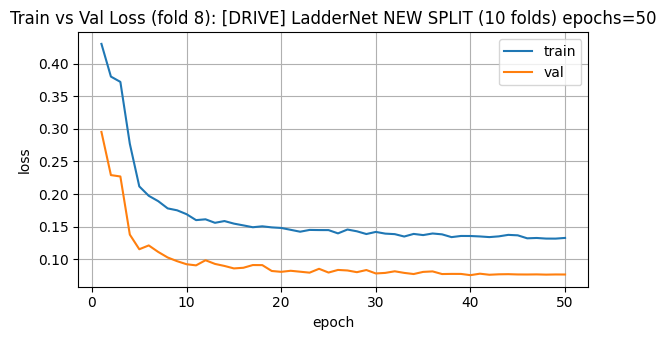

	 TRAIN vs VAL SAVED TO: ..\..\..\..\pth\LadderNet_DRIVE_NEWSPLIT\visuals\TrainVsVal__fold08.png


C:\Users\s1005\AppData\Local\Temp\ipykernel_14808\1133918526.py:123: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=D

=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.7161
Specificity    : 0.9892
clDice         : 0.7651
Accuracy       : 0.9657
Dice           : 0.7789
IoU            : 0.6393
Precision      : 0.8603
FPR            : 0.0108
FDR            : 0.1397
Dice_thin      : 0.4817
Dice_thick     : 0.6571
ROC_AUC        : 0.9801
PR_AUC         : 0.8794
-- Micro (pooled over all pixels) --
Sensitivity    : 0.7134
Specificity    : 0.9892
F1/Dice        : 0.7796
Accuracy       : 0.9657
IoU            : 0.6389
Precision      : 0.8595
FPR            : 0.0108
FDR            : 0.1405
ROC_AUC        : 0.9796
PR_AUC         : 0.8769


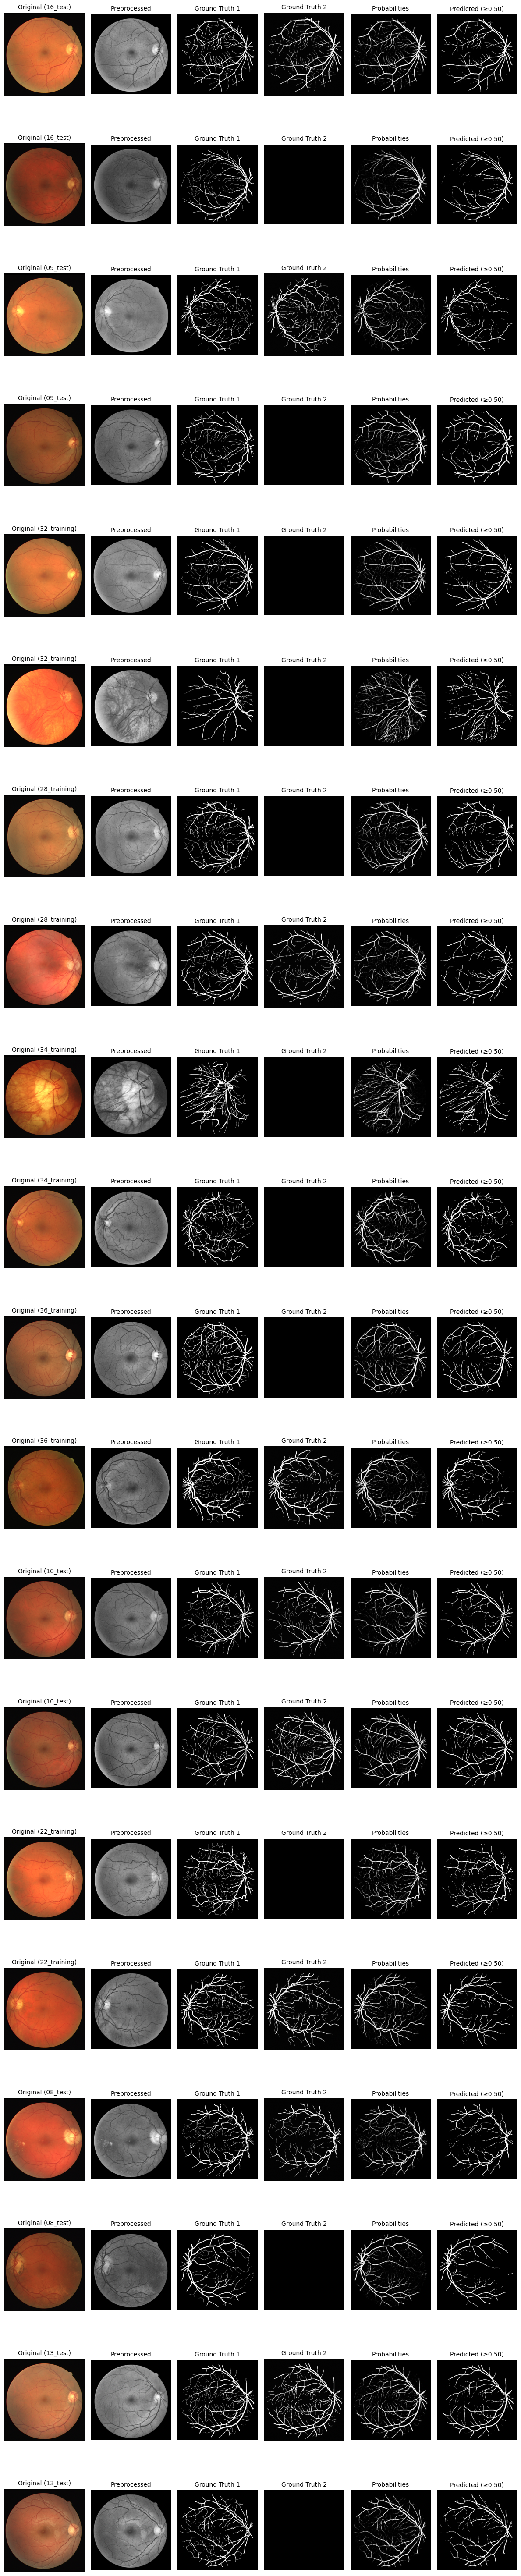

	== Visualization SAVED TO FILE: ..\..\..\..\pth\LadderNet_DRIVE_NEWSPLIT\visuals\testSet__fold08.png ==

========== LadderNet DRIVE NEW SPLIT, Fold 10/10 ==========

	 Chosen test subjects: [20, 23, 33, 27, 24, 1, 2, 19, 31, 28, 7, 10, 8, 16, 29, 11, 12, 34, 36, 21]

[F09 E001] train=0.4288 val=0.3235 lr=1.20e-04 time=16.8s
	CHECKPOINT SAVED: ..\..\..\..\pth\LadderNet_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold09.pth
[F09 E002] train=0.3974 val=0.2409 lr=1.80e-04 time=16.7s
	CHECKPOINT SAVED: ..\..\..\..\pth\LadderNet_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold09.pth
[F09 E003] train=0.3642 val=0.1724 lr=2.40e-04 time=16.7s
	CHECKPOINT SAVED: ..\..\..\..\pth\LadderNet_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold09.pth
[F09 E004] train=0.2470 val=0.1094 lr=3.00e-04 time=16.7s
	CHECKPOINT SAVED: ..\..\..\..\pth\LadderNet_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold09.pth
[F09 E005] train=0.2117 val=0.1092 lr=3.00e-04 time=16.8s
	CHECKPOINT SAVED: ..\..\..\..\pth\LadderNet_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold09.

In [ ]:

all_metrics, summary = run_drive_experiment(
    model_name=MODEL_NAME,
    dataset=DATASET,
    V_MULT=V_MULT,
    root=DATASET_ROOT,
    label_folder=DATASET_LABELFOLDER,
    epochs=EPOCHS,
    warmup=warmup_epochs,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    patch_train=True,
    patch_size=PATCH_SIZE,
    vessel_bias_p=VESSEL_BIAS,
    threshold_eval=THRESHOLD_EVAL,
    folds=FOLDS,
    fold_id=FOLD_ID,   #starts at any fold_id
    save_ckpt=SAVE_CKPT,
    save_viz=SAVE_VIZ,
    title=TITLE,
    save_logs=SAVE_LOGS,

    chckpnt_paths= [
        r"..\..\..\..\pth\LadderNet_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold00.pth",
        r"..\..\..\..\pth\LadderNet_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold01.pth",
        r"..\..\..\..\pth\LadderNet_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold02.pth",
        r"..\..\..\..\pth\LadderNet_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold03.pth",
        r"..\..\..\..\pth\LadderNet_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold04.pth",
        r"..\..\..\..\pth\LadderNet_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold05.pth",
        r"..\..\..\..\pth\LadderNet_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold06.pth",
        r"..\..\..\..\pth\LadderNet_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold07.pth",

         #"..\..\..\..\pth\FR-UNet_STARE_NEWSPLIT\checkpoints\STARE_fold00.pth",
         #"..\..\..\..\pth\FR-UNet_STARE_NEWSPLIT\checkpoints\STARE_fold01.pth",
         #"..\..\..\..\pth\FR-UNet_STARE_NEWSPLIT\checkpoints\STARE_fold02.pth"

    ]
)



In [ ]:
MODEL_NAME_2 = "LWNet"
TITLE_2     = f"[{DATASET}] {MODEL_NAME_2} NEW SPLIT ({FOLDS} folds) epochs={EPOCHS}"
SAVE_ROOT_2 = Path(f"../../../../pth/{MODEL_NAME}_{DATASET}_NEWSPLIT")     # a clean experiment folder
SAVE_CKPT_2 = SAVE_ROOT_2 / "checkpoints"
SAVE_PRED_2 = SAVE_ROOT_2 / "predictions"   # per-image logits/prob/masks
SAVE_VIZ_2  = SAVE_ROOT_2 / "visuals"       # PNG overlays per test image
SAVE_LOGS_2 = SAVE_ROOT_2 / "logs"
for d in [SAVE_ROOT_2, SAVE_CKPT_2, SAVE_PRED_2, SAVE_VIZ_2, SAVE_LOGS_2]: d.mkdir(parents=True, exist_ok=True)
FOLDS = 10
FOLD_ID = 0

In [ ]:

all_metrics, summary = run_drive_experiment(
    model_name=MODEL_NAME_2,
    dataset=DATASET,
    V_MULT=V_MULT,
    root=DATASET_ROOT,
    label_folder=DATASET_LABELFOLDER,
    epochs=EPOCHS,
    warmup=warmup_epochs,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    patch_train=True,
    patch_size=PATCH_SIZE,
    vessel_bias_p=VESSEL_BIAS,
    threshold_eval=THRESHOLD_EVAL,
    folds=FOLDS,
    fold_id=FOLD_ID,   #starts at any fold_id
    save_ckpt=SAVE_CKPT_2,
    save_viz=SAVE_VIZ_2,
    title=TITLE_2,
    save_logs=SAVE_LOGS_2,

    chckpnt_paths= [
        #"/content/drive/MyDrive/UNet Testing Template src/comparative/pth/UNet_DRIVE_NEWSPLIT/checkpoints/DRIVE_fold00.pth",
         #"..\..\..\..\pth\FR-UNet_STARE_NEWSPLIT\checkpoints\STARE_fold00.pth",
         #"..\..\..\..\pth\FR-UNet_STARE_NEWSPLIT\checkpoints\STARE_fold01.pth",
         #"..\..\..\..\pth\FR-UNet_STARE_NEWSPLIT\checkpoints\STARE_fold02.pth"

    ]
)

